In [5]:
!pip install prophet scikit-learn seaborn matplotlib

In [7]:
import pandas as pd
import numpy as np

# Mutlak yolunuzu kullanıyoruz
VERI_YOLU = r"C:\Users\ozlem\OneDrive\Belgeler\GitHub\e-ticaret-satis-tahmini\data\Amazon Sale Report.csv" 

# --- 1. VERİ YÜKLEME ---
try:
    # 'Amazon Sale Report' verisi bazen 'ISO-8859-1' veya 'latin-1' encoding ister
    df = pd.read_csv(VERI_YOLU, encoding='ISO-8859-1')
    print("✅ Ham Veri başarıyla yüklendi.")
except Exception as e:
    print(f"HATA: Veri yüklenirken hata oluştu: {e}")
    exit()

# --- 3. TEMİZLİK VE ZAMAN SERİSİ İÇİN DÖNÜŞÜM ---

# 3.1. Kritere Uymayan Satışları Filtreleme (Sadece Gerçekleşen Satışlar)
# Tahminimizi sadece başarıyla gönderilen veya teslim edilen satışlar üzerine kuruyoruz.
BASARILI_DURUMLAR = ['Shipped', 'Shipped - Delivered to Buyer', 'Delivered']
df = df[df['Status'].isin(BASARILI_DURUMLAR)].copy()
print("✅ Başarılı satışlar (Shipped/Delivered) filtrelendi.")

# 3.2. Kritik Sütunların Tipini Ayarlama
# Amount (Satış Miktarı/Geliri) sütununda eksik değerler olabilir.
df.dropna(subset=['Amount', 'Date'], inplace=True) 

# Amount sütununu sayısal (float) hale getirme
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')
df.dropna(subset=['Amount'], inplace=True) # Sayısala çevrilemeyenleri de atıyoruz.

# --- 4. HEDEF DEĞER (y) HESAPLAMA: GÜNLÜK TOPLAM GELİR ---

# 4.1. Tarih (ds) OLUŞTURMA VE DÖNÜŞÜM
# Tarih formatı 'MM-DD-YY' olduğu için bu formatı belirtmeliyiz.
df['Date'] = pd.to_datetime(df['Date'], format='%m-%d-%y')
print("✅ 'Date' (Tarih) sütunu datetime formatına dönüştürüldü.")

# 4.2. Günlük Toplam Satışı Hesaplama (Zaman Serisi Formatı)
# Zaman serisi analizi için veriyi günlük bazda gruplayıp Amount (Gelir) toplamını alıyoruz.
df_ts = df.groupby(df['Date'].dt.date)['Amount'].sum().reset_index()

# Sütun adlarını zaman serisi kütüphanelerinin istediği formata çevirme (ds ve y)
df_ts.rename(columns={'Date': 'ds', 'Amount': 'y'}, inplace=True)

# ds sütununu tekrar datetime olarak ayarla
df_ts['ds'] = pd.to_datetime(df_ts['ds'])

print("\n" + "="*70)
print("       ZAMAN SERİSİ İÇİN HAZIRLANMIŞ VERİ (df_ts)")
print("="*70)
print(f"Toplam Gün Sayısı: {len(df_ts)}")
print(f"Başlangıç Tarihi: {df_ts['ds'].min()}")
print(f"Bitiş Tarihi: {df_ts['ds'].max()}")
print("\nİlk 5 Satır:")
print(df_ts.head())

# İleride kullanmak üzere nihai veriyi kaydet
# Eğer data klasörünüzde değilse, yolu kontrol edin:
# df_ts.to_csv(r'C:\Users\ozlem\OneDrive\Belgeler\GitHub\e-ticaret-satis-tahmini\data\temiz_gunluk_satis_verisi.csv', index=False)

C:\Users\ozlem\AppData\Local\Temp\ipykernel_11628\2152942398.py:10: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(VERI_YOLU, encoding='ISO-8859-1')


✅ Ham Veri başarıyla yüklendi.
✅ Başarılı satışlar (Shipped/Delivered) filtrelendi.
✅ 'Date' (Tarih) sütunu datetime formatına dönüştürüldü.

       ZAMAN SERİSİ İÇİN HAZIRLANMIŞ VERİ (df_ts)
Toplam Gün Sayısı: 91
Başlangıç Tarihi: 2022-03-31 00:00:00
Bitiş Tarihi: 2022-06-29 00:00:00

İlk 5 Satır:
          ds         y
0 2022-03-31   94183.0
1 2022-04-01  767000.0
2 2022-04-02  804455.0
3 2022-04-03  911517.0
4 2022-04-04  802266.0


14:44:12 - cmdstanpy - INFO - Chain [1] start processing
14:44:13 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet Modeli Başarıyla Eğitildi.
✅ Gelecek 7 günlük tahmin çerçevesi oluşturuldu.

     PROPHET MODELİ PERFORMANS METRİKLERİ
MAE (Ortalama Mutlak Hata): 286,287.23 INR
RMSE (Kök Ortalama Kare Hata): 319,775.43 INR


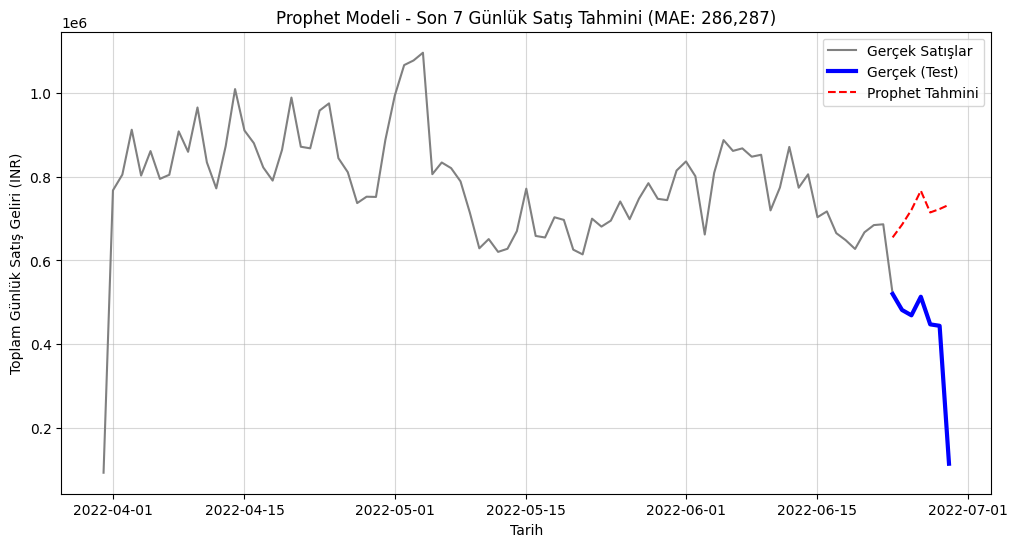


✅ Prophet tahmini tamamlandı ve görsel kaydedildi.


In [9]:
# Gerekli kütüphaneleri yükleme (Prophet, scikit-learn ve diğerleri)
# Eğer kurulu değilse, yeni bir hücrede !pip install prophet scikit-learn seaborn matplotlib yazıp çalıştırın!
import os # Kaydetmek için bu kritik!
from prophet import Prophet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. VERİ BÖLÜMLEME ---

TATIL_GUNU_SAYISI = 7 
df_train = df_ts.iloc[:-TATIL_GUNU_SAYISI]
df_test = df_ts.iloc[-TATIL_GUNU_SAYISI:]

# --- 2. PROPHET MODELİ EĞİTİMİ ---

m = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=False
)

m.fit(df_train)
print("✅ Prophet Modeli Başarıyla Eğitildi.")

# --- 3. TAHMİN ÇERÇEVESİ OLUŞTURMA ---

future = m.make_future_dataframe(periods=TATIL_GUNU_SAYISI, include_history=False)
print(f"✅ Gelecek {TATIL_GUNU_SAYISI} günlük tahmin çerçevesi oluşturuldu.")
forecast = m.predict(future)

# --- 4. MODEL PERFORMANSI VE GÖRSELLEŞTİRME ---

y_pred_prophet = forecast['yhat'].values
y_true = df_test['y'].values

mae_prophet = mean_absolute_error(y_true, y_pred_prophet)
rmse_prophet = np.sqrt(mean_squared_error(y_true, y_pred_prophet))

print("\n" + "="*50)
print("     PROPHET MODELİ PERFORMANS METRİKLERİ")
print("="*50)
print(f"MAE (Ortalama Mutlak Hata): {mae_prophet:,.2f} INR")
print(f"RMSE (Kök Ortalama Kare Hata): {rmse_prophet:,.2f} INR")

# Tahminleri görselleştirme
plt.figure(figsize=(12, 6))
plt.plot(df_ts['ds'], df_ts['y'], label='Gerçek Satışlar', color='gray')
plt.plot(df_test['ds'], y_true, label='Gerçek (Test)', color='blue', linewidth=3)
plt.plot(df_test['ds'], y_pred_prophet, label='Prophet Tahmini', color='red', linestyle='--')
plt.title(f'Prophet Modeli - Son {TATIL_GUNU_SAYISI} Günlük Satış Tahmini (MAE: {mae_prophet:,.0f})')
plt.xlabel('Tarih')
plt.ylabel('Toplam Günlük Satış Geliri (INR)')
plt.legend()
plt.grid(True, alpha=0.5)

# Görseli kaydet
FIGURES_YOLU = r'C:\Users\ozlem\OneDrive\Belgeler\GitHub\e-ticaret-satis-tahmini\figures'
os.makedirs(FIGURES_YOLU, exist_ok=True)
plt.savefig(os.path.join(FIGURES_YOLU, 'prophet_tahmini.png'))
plt.show()

print("\n✅ Prophet tahmini tamamlandı ve görsel kaydedildi.")
